In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

from tensorflow.keras.optimizers import Adam

In [ ]:
train_df = pd.read_csv(
    "/content/drive/MyDrive/FP_AI_2026/data/train.csv"
)

val_df = pd.read_csv(
    "/content/drive/MyDrive/FP_AI_2026/data/val.csv"
)

test_df = pd.read_csv(
    "/content/drive/MyDrive/FP_AI_2026/data/test.csv"
)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(800, 2)
(100, 2)
(100, 2)


In [ ]:
X_train = train_df["Sample_Code"].astype(str)
y_train = train_df["Label"]

X_val = val_df["Sample_Code"].astype(str)
y_val = val_df["Label"]

X_test = test_df["Sample_Code"].astype(str)
y_test = test_df["Label"]

In [ ]:
MAX_WORDS = 10000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>",
    filters=""
)

tokenizer.fit_on_texts(X_train)

print(
    "Vocabulary Size:",
    len(tokenizer.word_index)
)

Vocabulary Size: 23582


In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
lengths = pd.Series(
    [len(x) for x in X_train_seq]
)

print(
    lengths.describe(
        percentiles=[
            .50,
            .75,
            .90,
            .95,
            .99
        ]
    )
)

count     800.000000
mean      128.118750
std       169.680004
min         1.000000
50%        69.000000
75%       141.000000
90%       292.100000
95%       483.350000
99%       810.460000
max      1813.000000
dtype: float64


In [ ]:
MAX_LEN = 500

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print(X_train_pad.shape)
print(X_val_pad.shape)
print(X_test_pad.shape)

(800, 500)
(100, 500)
(100, 500)


In [ ]:
cnn_model = Sequential([

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_length=MAX_LEN
    ),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu"
    ),

    GlobalMaxPooling1D(),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(
        0.3
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = Adam(
    learning_rate=0.0005
)

cnn_model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
start_train = time.time()

history = cnn_model.fit(
    X_train_pad,
    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=20,
    batch_size=32,

    callbacks=[
        early_stop
    ]
)

end_train = time.time()

training_time = (
    end_train - start_train
)

print(
    f"Training Time: {training_time:.2f} seconds"
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.6137 - loss: 0.6859 - val_accuracy: 0.7700 - val_loss: 0.6743
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9025 - loss: 0.6380 - val_accuracy: 0.8300 - val_loss: 0.6300
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9388 - loss: 0.5468 - val_accuracy: 0.9100 - val_loss: 0.5266
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9638 - loss: 0.3702 - val_accuracy: 0.9400 - val_loss: 0.3475
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9750 - loss: 0.1911 - val_accuracy: 0.9600 - val_loss: 0.2056
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9925 - loss: 0.0844 - val_accuracy: 0.9300 - val_loss: 0.1636
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9987 - loss: 0.0447 - val_accuracy: 0.9500 - val_loss: 0.1197
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0252 - val_accuracy: 0.9600 - val_lo

In [ ]:
print("=" * 50)
print("MODEL COMPLEXITY")
print("=" * 50)

cnn_model.summary()

total_params = cnn_model.count_params()

print("\nTotal Parameters:")
print(f"{total_params:,}")

MODEL COMPLEXITY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (32, 500, 128)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (32, 496, 128)         │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (32, 128)              │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 1)                │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,111,109 (15.68 MB)

 Trainable params: 1,370,369 (5.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,740,740 (10.46 MB)


Total Parameters:
1,370,369


In [ ]:
cnn_parameters = cnn_model.count_params()

print(
    f"Total Parameters: {cnn_parameters:,}"
)

Total Parameters: 1,370,369


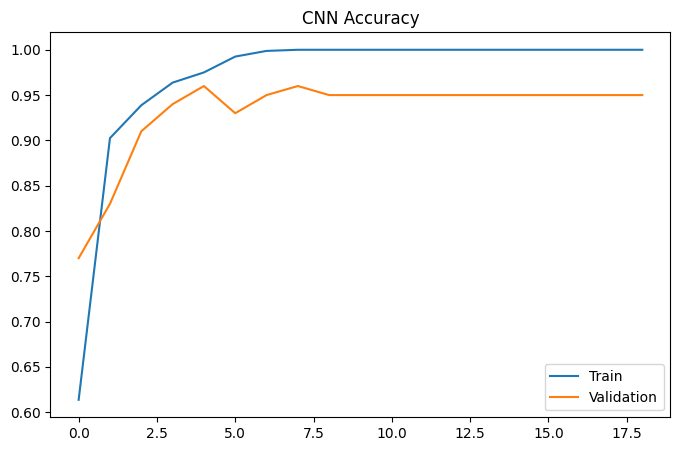

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Train"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.title("CNN Accuracy")

plt.legend()

plt.show()

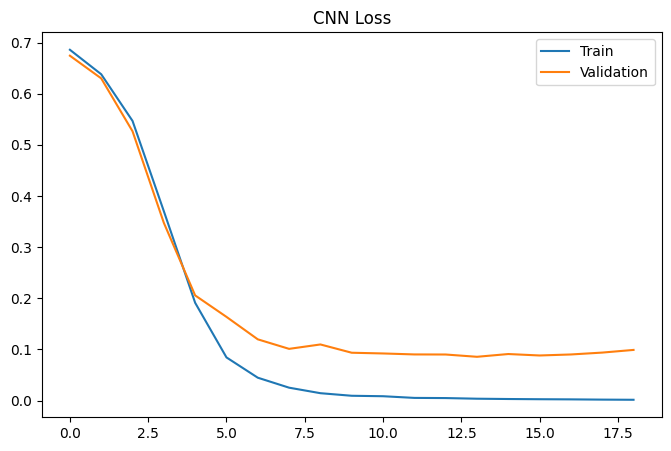

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Train"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.title("CNN Loss")

plt.legend()

plt.show()

In [ ]:
start_inference = time.time()

y_prob = cnn_model.predict(
    X_test_pad
)

end_inference = time.time()

inference_time = (
    end_inference -
    start_inference
)

print(
    f"Inference Time: {inference_time:.4f} seconds"
)

print(
    f"Average/sample: {inference_time/len(X_test_pad):.6f} seconds"
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Inference Time: 0.6255 seconds
Average/sample: 0.006255 seconds


In [ ]:
y_prob = cnn_model.predict(
    X_test_pad
)

y_pred = (
    y_prob > 0.5
).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [ ]:
acc = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_prob
)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

Accuracy : 0.9600
Precision: 0.9423
Recall   : 0.9800
F1 Score : 0.9608
AUC      : 0.9980


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Human",
            "AI"
        ]
    )
)

              precision    recall  f1-score   support

       Human       0.98      0.94      0.96        50
          AI       0.94      0.98      0.96        50

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



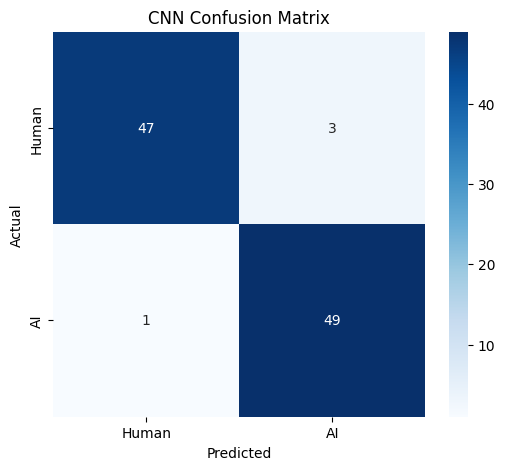

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Human","AI"],
    yticklabels=["Human","AI"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "CNN Confusion Matrix"
)

plt.show()

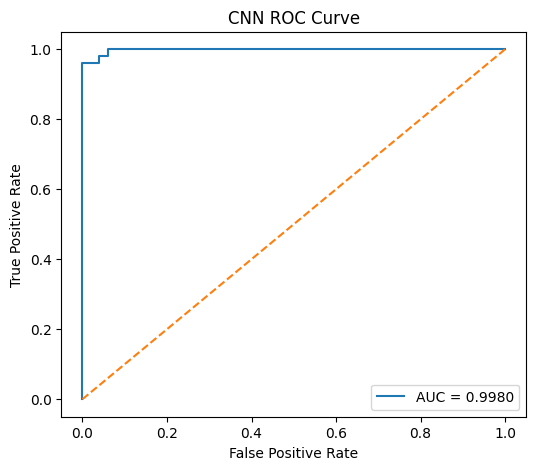

In [ ]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "CNN ROC Curve"
)

plt.legend()

plt.show()

In [ ]:
cnn_model.save(
    "/content/drive/MyDrive/FP_AI_2026/models/cnn_model.h5"
)

In [ ]:
import pickle

TOKENIZER_PATH = (
    "/content/drive/MyDrive/FP_AI_2026/models/tokenizer.pkl"
)

with open(
    TOKENIZER_PATH,
    "wb"
) as f:

    pickle.dump(
        tokenizer,
        f
    )

print(
    "Tokenizer saved successfully"
)

Tokenizer saved successfully


In [ ]:
import pickle

with open(
    "/content/drive/MyDrive/FP_AI_2026/models/tokenizer.pkl",
    "rb"
) as f:

    loaded_tokenizer = pickle.load(
        f
    )

print(
    "Tokenizer Loaded"
)

print(
    "Vocabulary Size:",
    len(
        loaded_tokenizer.word_index
    )
)

Tokenizer Loaded
Vocabulary Size: 23582


In [ ]:
compare_path = (
    "/content/drive/MyDrive/FP_AI_2026/compare"
)

cnn_results = pd.DataFrame([
    {
        "Model":
            "CNN",

        "Accuracy":
            acc,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1":
            f1,

        "AUC":
            auc,

        "Training_Time":
            training_time,

        "Inference_Time":
            inference_time,

        "Parameters":
            cnn_parameters
    }
])

cnn_results

cnn_results.to_csv(
    f"{compare_path}/cnn_results.csv",
    index=False
)

print(
    "CNN results saved"
)

CNN results saved
